# Setting up a relative binding free energy network

This tutorial gives a step-by-step process to set up a relative binding free energy (RBFE) simulation campaign using OpenFE. This tutorial is designed as an accompaniment to the CLI tutorial found in the same directory as this notebook.

With the CLI, all the steps here were performed by the `openfe plan-rbfe-network` command. However, that command offers little room for customization. Using the Python interface gives us the ability to customize all aspects of how our simulation runs. This tutorial provides a step-by-step Python guide to reproducing the setup done in the CLI tutorial, highlighting areas where the Python interface enables customization.

In [1]:
import multiprocessing as mp
import os
import re
from pathlib import Path

import MDAnalysis as mda
import mdtraj as md
import openfe
from MDAnalysis.analysis import align
from openfe import (
    AlchemicalNetwork,
    ChemicalSystem,
    ProteinComponent,
    SmallMoleculeComponent,
    SolventComponent,
    Transformation,
)
from openfe.protocols.openmm_rfe import RelativeHybridTopologyProtocol
from openfe.protocols.openmm_septop import SepTopProtocol
from openfe.protocols.openmm_utils.charge_generation import bulk_assign_partial_charges
from openfe.protocols.openmm_utils.omm_settings import OpenFFPartialChargeSettings
from openfe.setup import RBFEAlchemicalNetworkPlanner, RHFEAlchemicalNetworkPlanner
from openfe.setup.atom_mapping import KartografAtomMapper, LomapAtomMapper
from openfe.setup.atom_mapping.lomap_scorers import (
    atomic_number_score,
    default_lomap_score,
    ecr_score,
    mcsr_score,
    mncar_score,
)
from openfe.setup.ligand_network_planning import (
    generate_lomap_network,
    generate_maximal_network,
    generate_minimal_redundant_network,
    generate_minimal_spanning_network,
    generate_network_from_indices,
    generate_network_from_names,
    generate_radial_network,
)
from openfe.utils.atommapping_network_plotting import plot_atommapping_network
from openff.units import unit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Descriptors3D import Asphericity

from mdpp.plots import draw_mols, make_atom_labels_3d, view_mol_3d, view_traj_3d
from mdpp.prep import assign_topology, fix_pdb

## Configuration

Define input paths (complex PDBs, SMILES file), chain identifiers, and simulation parameters (temperature, pH, lambda windows, production length). All intermediate files are written under a working directory.

In [2]:
COMPLEX_DIR = Path("pdbs")
SMILES_PATH = Path("ligands_amp_fep.smi")
PROTEIN_CHAIN_ID = "A"
LIGAND_CHAIN_ID = "B"

WORKING_DIR = Path("tmp")
WORKING_DIR.mkdir(exist_ok=True)

ALIGN_DIR = WORKING_DIR / "align"
ALIGN_DIR.mkdir(exist_ok=True)
PROTEIN_PATH = WORKING_DIR / "protein.pdb"
FIXED_PROTEIN_PATH = WORKING_DIR / "protein_fixed.pdb"
LIGAND_DIR = WORKING_DIR / "ligands"
LIGAND_DIR.mkdir(exist_ok=True)
CHARGED_LIGAND_DIR = WORKING_DIR / "charged_ligands"
CHARGED_LIGAND_DIR.mkdir(exist_ok=True)
LIGAND_NETWORK_PATH = WORKING_DIR / "ligand_network.graphml"
TRANSFORMATION_DIR = WORKING_DIR / "transformations"
TRANSFORMATION_DIR.mkdir(exist_ok=True)
SEPTOP_TRANSFORMATION_DIR = WORKING_DIR / "septop_transformations"
SEPTOP_TRANSFORMATION_DIR.mkdir(exist_ok=True)

# Simulation parameters
LAMBDA_WINDOWS = 51
N_REPLICAS = LAMBDA_WINDOWS
PH = 7.0
PRODUCTION_LENGTH = 20.0
REPEATS = 1
TEMPERATURE = 298.15
LOMAP_MAPPER_SEED = "O=C(CCCC[C,N])OP(OC[C@H]1O[C@@H](n2cnc3c2ncnc3N)[C@H](O)[C@@H]1O)([O-])=O"  # SMARTS string for MCS search

## Prepare structures from complex PDB files

Each complex PDB file contains a protein and ligand. We select the reference protein as the complex bound to the most aspherical ligand (highest Asphericity descriptor), align all other complexes to it, and assign correct bond orders from the SMILES file using `assign_topology`. The reference protein is expected to already be fixed and protonated (via `fix_pdb`) from a prior run.

In [3]:
def _match_ligand(stem: str, smi_d: dict[str, Chem.Mol]) -> str | None:
    """Return the first SMILES-dict key that appears as a whole word in *stem*.

    Matching uses word-boundary assertions so that e.g. ``"lig1"`` matches
    the stem ``"complex_lig1_chainA"`` but not ``"complex_lig10_chainA"``.

    Args:
        stem: PDB filename stem (without extension) to search in.
        smi_d: Mapping of ligand names to RDKit template molecules.

    Returns:
        The matched ligand name, or ``None`` if no key matches.
    """
    return next(
        (n for n in smi_d if re.search(rf"(?<![A-Za-z\d]){re.escape(n)}(?![A-Za-z\d])", stem)),
        None,
    )

In [4]:
# Build SMILES template dict from .smi file
smi_suppl = Chem.SmilesMolSupplier(str(SMILES_PATH), sanitize=True)
smiles_dict = {mol.GetProp("_Name"): mol for mol in smi_suppl if mol is not None}

# Pass 1: extract ligands and compute Asphericity to select reference structure
ligand_asphericity = {}
ligand_volume = {}
for pdb_file in sorted(COMPLEX_DIR.glob("*.pdb")):
    # Pair ligand name with PDB filename; if no match, skip
    lig_name = _match_ligand(pdb_file.stem, smiles_dict)
    if lig_name is None:
        continue
    ligand_pdb = ALIGN_DIR / f"{lig_name}.pdb"
    u = mda.Universe(pdb_file)
    u.select_atoms(f"chainID {LIGAND_CHAIN_ID}").write(ligand_pdb)
    rdkit_mol = Chem.MolFromPDBFile(str(ligand_pdb), sanitize=True, removeHs=True)
    rdkit_mol = assign_topology(rdkit_mol, smiles_dict[lig_name])
    ligand_asphericity[pdb_file] = Asphericity(rdkit_mol)
    ligand_volume[pdb_file] = AllChem.ComputeMolVolume(rdkit_mol)

ref_pdb = max(ligand_asphericity, key=ligand_asphericity.get)
print(f"{'File':<40} {'Asphericity':>12} {'Volume (A^3)':>12}")
for pdb_file in sorted(ligand_asphericity):
    marker = " <-- ref" if pdb_file == ref_pdb else ""
    print(
        f"{pdb_file.name:<40} {ligand_asphericity[pdb_file]:>12.4f}"
        f" {ligand_volume[pdb_file]:>12.2f}{marker}"
    )

/apps/miniconda3/envs/openfe/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:885: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn(
/apps/miniconda3/envs/openfe/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(
[19:11:42] WARNING: More than one matching pattern found - picking one

[19:11:42] WARNING: More than one matching pattern found - picking one

[19:11:42] WARNING: More than one matching pattern found - picking one

[19:11:43] WARNING: More than one matching pattern found - picking one

[19:11:43] WARNING: More than one matching pattern found - picking one

[19:11:43] WARNING: More than one matching pattern found - picking one



File                                      Asphericity Volume (A^3)
FLE03_A7_AMP_3a7r_model_0.pdb                  0.2812       424.86
FLE03_ACCO_AMP_3a7r_model_0.pdb                0.5064       525.38
FLE03_ACO_AMP_3a7r_model_0.pdb                 0.5040       525.57
FLE03_BCN_AMP_3a7r_model_0.pdb                 0.5320       525.53 <-- ref
FLE03_C5_AMP_3a7r_model_0.pdb                  0.3288       432.62
FLE03_LA_AMP_3a7r_model_0.pdb                  0.3093       427.05
FLE03_OCTA_AMP_3a7r_model_0.pdb                0.2177       403.29
FLE03_P5_AMP_3a7r_model_0.pdb                  0.4574       477.66


[19:11:43] WARNING: More than one matching pattern found - picking one

[19:11:43] WARNING: More than one matching pattern found - picking one



In [5]:
# Pass 2: align all complexes to reference, extract ligands and reference protein
ref_u = mda.Universe(ref_pdb)

for pdb_file in sorted(COMPLEX_DIR.glob("*.pdb")):
    lig_name = _match_ligand(pdb_file.stem, smiles_dict)
    if lig_name is None:
        continue
    mob_u = mda.Universe(pdb_file)
    old_rmsd, new_rmsd = align.alignto(
        mob_u.select_atoms("protein and backbone"),
        ref_u.select_atoms("protein and backbone"),
    )
    ligand_pdb = ALIGN_DIR / f"{lig_name}_aligned.pdb"
    mob_u.select_atoms(f"chainID {LIGAND_CHAIN_ID}").write(ligand_pdb)
    rdkit_mol = Chem.MolFromPDBFile(str(ligand_pdb), removeHs=True)
    rdkit_mol = assign_topology(rdkit_mol, smiles_dict[lig_name])
    rdkit_mol.SetProp("_Name", lig_name)
    Chem.MolToMolFile(rdkit_mol, str(LIGAND_DIR / f"{lig_name}.sdf"))

    print(f"{lig_name}  (RMSD: {old_rmsd:.3f} -> {new_rmsd:.3f} A)")
    view_mol_3d(rdkit_mol, width=400, height=300, show=True)
    if pdb_file == ref_pdb:
        mob_u.select_atoms(f"chainID {PROTEIN_CHAIN_ID}").write(PROTEIN_PATH)

A7_AMP  (RMSD: 26.254 -> 0.224 A)


[19:11:43] WARNING: More than one matching pattern found - picking one



3Dmol.js failed to load for some reason. Please check your browser console for error messages.

ACCO_AMP  (RMSD: 26.133 -> 0.277 A)


[19:11:43] WARNING: More than one matching pattern found - picking one



...

[19:11:43] WARNING: More than one matching pattern found - picking one



3Dmol.js failed to load for some reason. Please check your browser console for error messages.

P5_AMP  (RMSD: 39.265 -> 0.265 A)


[19:11:43] WARNING: More than one matching pattern found - picking one



3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [6]:
fix_pdb(PROTEIN_PATH, FIXED_PROTEIN_PATH, PH)
protein_traj = md.load_pdb(str(FIXED_PROTEIN_PATH))
view_traj_3d(protein_traj)

Missing atoms or failed protonation for ARG 181 A (ARG) -- please check the structure
Group (ARG) for  1411-  CZ   181-ARG (A) [  -7.437   -9.102   -5.829] C
Expected 8 interaction atoms for acids, found:
              1413- NH2   181-ARG (A) [  -6.889   -8.106   -6.518] N
              1410-  NE   181-ARG (A) [  -8.736   -9.371   -5.975] N
              1412- NH1   181-ARG (A) [  -6.679   -9.822   -5.008] N
                 0- HH2   181-ARG (A) [  -5.902   -8.169   -6.315] H
                 0-  HE   181-ARG (A) [  -9.265   -8.798   -6.617] H
                 0-HH11   181-ARG (A) [  -5.697   -9.608   -4.910] H
                 0-HH12   181-ARG (A) [  -7.085  -10.583   -4.482] H
Expected 3 interaction atoms for bases, found:
              1413- NH2   181-ARG (A) [  -6.889   -8.106   -6.518] N
              1410-  NE   181-ARG (A) [  -8.736   -9.371   -5.975] N
              1412- NH1   181-ARG (A) [  -6.679   -9.822   -5.008] N
/apps/miniconda3/envs/openfe/lib/python3.13/site-packages/

NGLWidget()

## Loading the ligands

We load the pre-aligned ligand SDF files produced in the previous step. Each file has correct bond orders and hydrogens assigned via `assign_topology`.

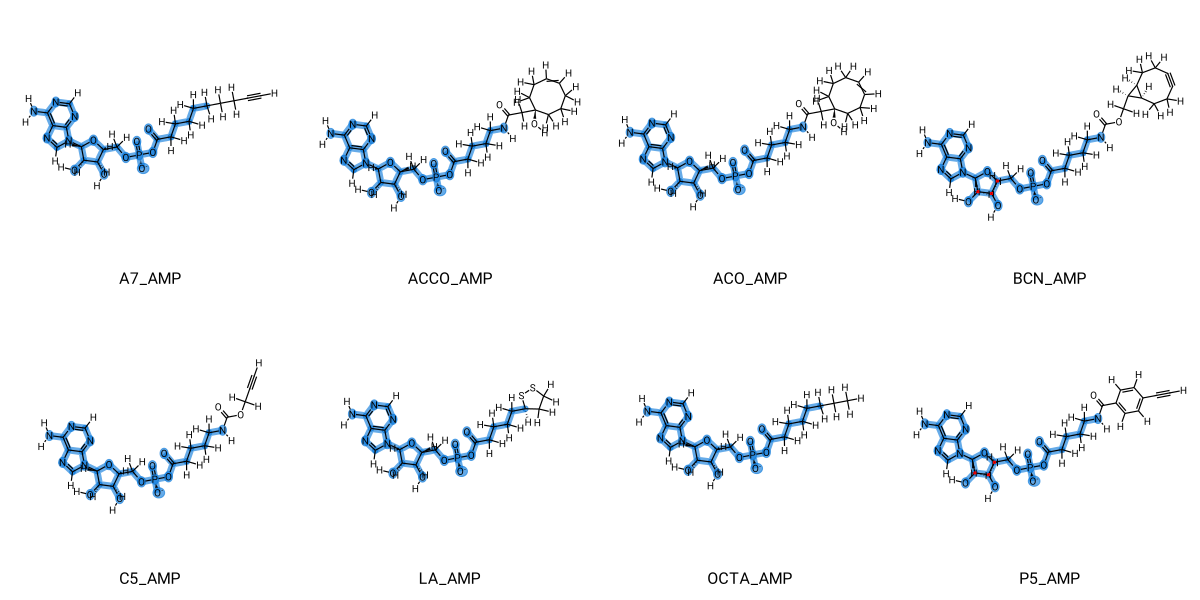

In [7]:
ligands_rdmol = sorted(
    [Chem.MolFromMolFile(str(f), removeHs=False) for f in sorted(LIGAND_DIR.glob("*.sdf"))],
    key=lambda m: m.GetProp("_Name"),
)
ligands = [SmallMoleculeComponent(mol, name=mol.GetProp("_Name")) for mol in ligands_rdmol]

ligand_labels = [mol.GetProp("_Name") if mol.HasProp("_Name") else "" for mol in ligands_rdmol]
seed_pattern = Chem.MolFromSmarts(LOMAP_MAPPER_SEED) if LOMAP_MAPPER_SEED.strip() else None

draw_mols(
    ligands_rdmol,
    legends=ligand_labels,
    pattern=seed_pattern,
    mols_per_row=4,
    sub_img_size=(300, 300),
)

## Charging the ligands

It is recommended to use a single set of charges for each ligand to ensure reproducibility between repeats or consistent charges between different legs of a calculation involving the same ligand, like a relative binding affinity calculation for example. 

Here we will use some utility functions from OpenFE which can assign partial charges to a series of molecules with a variety of methods which can be configured via the `OpenFFPartialChargeSettings` class. In this example 
we will charge the ligands using the `am1bcc` method from `ambertools` which is the default charge scheme used by OpenFE.

> **Warning:** AM1-BCC charge generation is slow (can take several minutes per ligand). To avoid recomputing charges on every run, the charged molecules are saved as SDF files to `CHARGED_LIGAND_DIR`. On subsequent runs, pre-existing charged SDFs are loaded directly from disk.

In [8]:
charged_sdfs = sorted(CHARGED_LIGAND_DIR.glob("*.sdf"))
if charged_sdfs:
    assert len(charged_sdfs) == len(ligands)
    charged_ligands = [SmallMoleculeComponent.from_sdf_file(str(f)) for f in charged_sdfs]
else:
    charge_settings = OpenFFPartialChargeSettings(
        partial_charge_method="am1bcc", off_toolkit_backend="ambertools"
    )

    charged_ligands = bulk_assign_partial_charges(
        molecules=ligands,
        overwrite=True,  # overwrite existing charges if exists
        method=charge_settings.partial_charge_method,
        toolkit_backend=charge_settings.off_toolkit_backend,
        generate_n_conformers=charge_settings.number_of_conformers,
        nagl_model=charge_settings.nagl_model,
        processors=mp.cpu_count(),  # use all available cores; faster than one per ligand
    )

    for smc in charged_ligands:
        sdf_path = CHARGED_LIGAND_DIR / f"{smc.name}.sdf"
        sdf_path.write_text(smc.to_sdf())

/apps/miniconda3/envs/openfe/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=2725061) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/apps/miniconda3/envs/openfe/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=2725061) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/apps/miniconda3/envs/openfe/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=2725061) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/apps/miniconda3/envs/openfe/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=2725061) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/apps/miniconda3/envs/openfe/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=2725061) is mult

In [9]:
for lig in charged_ligands:
    rdmol = lig.to_rdkit()
    labels = make_atom_labels_3d(
        rdmol,
        text_fn=lambda atom: f"{atom.GetDoubleProp('PartialCharge'):+.2f}",
        color_fn=lambda atom: "red" if atom.GetDoubleProp("PartialCharge") < 0 else "blue",
        base_style={
            "fontSize": 10,
            "showBackground": True,
            "backgroundOpacity": 0.6,
            "backgroundColor": "white",
        },
    )
    print(lig.name)
    view_mol_3d(
        rdmol,
        width=800,
        height=400,
        style={"stick": {}, "sphere": {"scale": 0.3}},
        labels=labels,
        show=True,
    )

LA_AMP


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

OCTA_AMP


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

A7_AMP


...

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

P5_AMP


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

ACO_AMP


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Creating the `LigandNetwork`

The first step is to create a `LigandNetwork`, which is a network with small molecules as nodes, and atom mappings, the description of how to alchemically mutate between the molecules, as its edges.

The pipeline for creating a `LigandNetwork` can involve three components:

* **Atom Mapper**: Proposes potential atom mappings (descriptions of the alchemical change) for pairs of ligands.
* **Scorer**: Given an atom mapping, provides an estimate of the quality of that mapping (higher scores are better).
* **Network Planner**: Creates the actual `LigandNetwork`; different network planners provide different strategies.

Each of these components could be replaced by other options.

In [10]:
lomap_mapper = LomapAtomMapper(
    time=20,  # Time out if MCS algorithm takes 20 seconds
    threed=True,  # Use atom positions to prune symmetric mappings
    max3d=1.0,  # Forbid mapping between atoms more than 1.0 Å apart
    element_change=True,  # Allow mappings that change an atoms element
    seed=LOMAP_MAPPER_SEED,  # Empty SMARTS string causes MCS search to start from scratch
    shift=False,  # Keep pre-aligned atom positions for 3D position checks
)
kartograf_mapper = KartografAtomMapper()

# Passing multiple atom mappers to the planner
mappers = [lomap_mapper, kartograf_mapper]
scorer = default_lomap_score
network_planner = generate_minimal_redundant_network

The exact call signature depends on the network planner: a minimal spanning network requires a score, whereas that is optional for a radial network (but a radial network needs the central ligand to be provided).

If a previously saved `graphml` network exists on disk, it is loaded directly; otherwise a new network is planned and written out for reuse:

Now we can look at the overall structure of the `LigandNetwork`:

INFO:	#################################
INFO:	Map Heavy Atoms 
INFO:	#################################
INFO:	Masking Atoms
INFO:	Build Distance Matrix
INFO:	Calculate Mapping
INFO:	Find Maximal overlapping connected sets of mapped atoms
INFO:	#################################
INFO:	Map Hydrogen Atoms: 
INFO:	#################################
INFO:	Masking Atoms
INFO:	Build Distance Matrix
INFO:	Calculate Mapping
INFO:	Find Maximal overlapping connected sets of mapped atoms
INFO:	Filtering bond breaks
INFO:	#################################
INFO:	Map Heavy Atoms 
INFO:	#################################
INFO:	Masking Atoms
INFO:	Build Distance Matrix
INFO:	Calculate Mapping
INFO:	Find Maximal overlapping connected sets of mapped atoms
INFO:	#################################
INFO:	Map Hydrogen Atoms: 
INFO:	#################################
INFO:	Masking Atoms
INFO:	Build Distance Matrix
INFO:	Calculate Mapping
INFO:	Find Maximal overlapping connected sets of mapped atoms
INFO:	Filtering 

Mapping:  11%|#         | 3/28 [00:04<00:34,  1.37s/it]

INFO:	#################################
INFO:	Map Heavy Atoms 
INFO:	#################################
INFO:	Masking Atoms
INFO:	Build Distance Matrix
INFO:	Calculate Mapping
INFO:	Find Maximal overlapping connected sets of mapped atoms
INFO:	#################################
INFO:	Map Hydrogen Atoms: 
INFO:	#################################
INFO:	Masking Atoms
INFO:	Build Distance Matrix
INFO:	Calculate Mapping
INFO:	Find Maximal overlapping connected sets of mapped atoms
INFO:	Filtering bond breaks
INFO:	#################################
INFO:	Map Heavy Atoms 
INFO:	#################################
INFO:	Masking Atoms
INFO:	Build Distance Matrix
INFO:	Calculate Mapping
INFO:	Find Maximal overlapping connected sets of mapped atoms
INFO:	#################################
INFO:	Map Hydrogen Atoms: 
INFO:	#################################
INFO:	Masking Atoms
INFO:	Build Distance Matrix
INFO:	Calculate Mapping
INFO:	Find Maximal overlapping connected sets of mapped atoms
INFO:	Filtering 

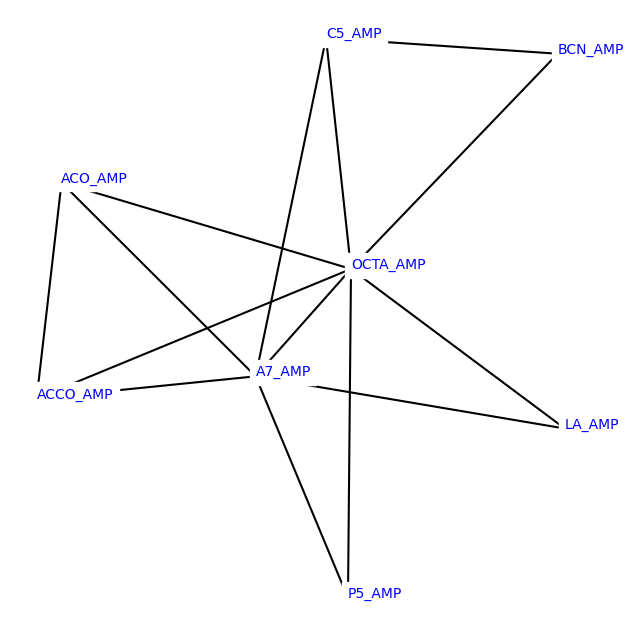

In [11]:
if LIGAND_NETWORK_PATH.exists():
    graphml_str = LIGAND_NETWORK_PATH.read_text(encoding="utf-8")
    ligand_network = openfe.LigandNetwork.from_graphml(graphml_str)
else:
    ligand_network = network_planner(ligands=charged_ligands, mappers=mappers, scorer=scorer)
    with LIGAND_NETWORK_PATH.open("w", encoding="utf-8") as f:
        f.write(ligand_network.to_graphml())

_ = plot_atommapping_network(ligand_network)

We can also inspect the individual atom mappings:

To get the score for this mapping, we inspect its `annotations` attribute. Arbitrary annotations can be added when a mapping is created, although our network generator only includes the score.

{'score': 0.18268352405273464}


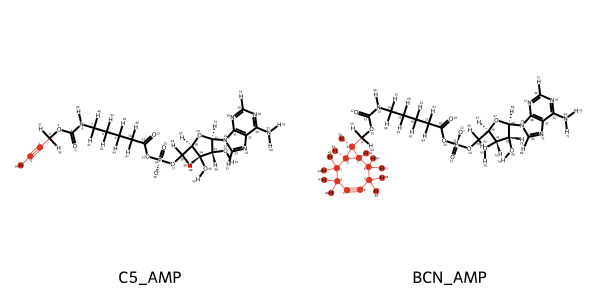

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'score': 0.21224797382674304}


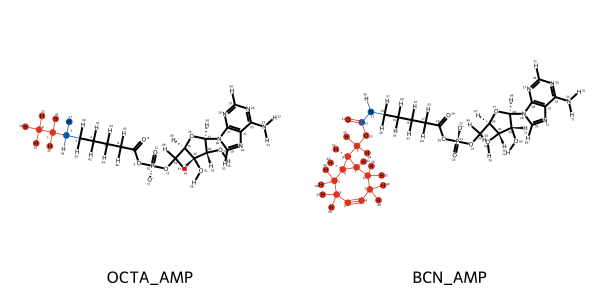

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'score': 0.23457028809379762}


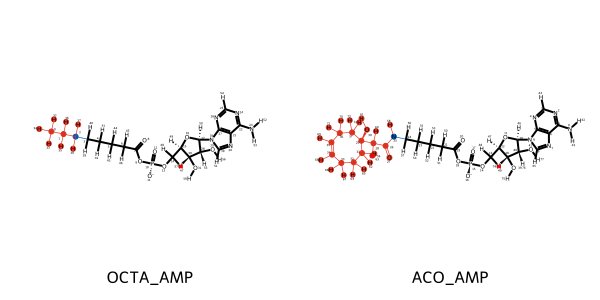

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'score': 0.19204990862075408}


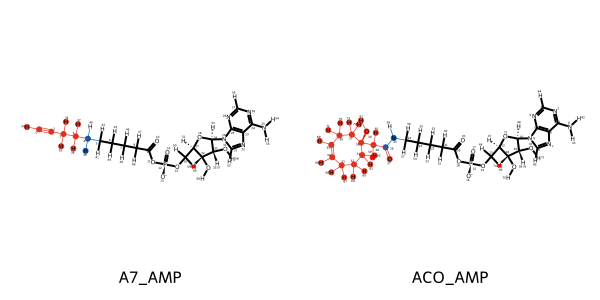

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'score': 0.2018965179946554}


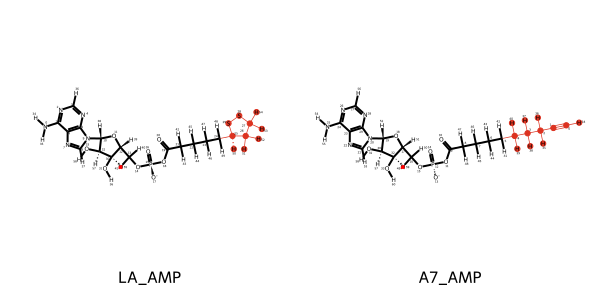

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'score': 0.42741493194872665}


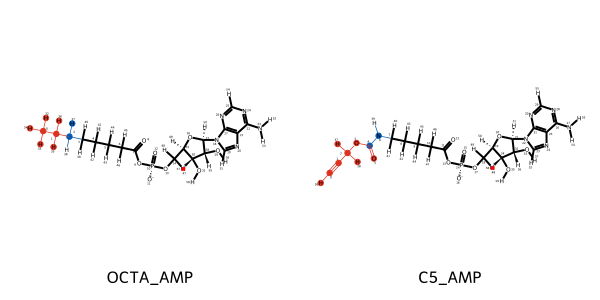

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'score': 0.23457028809379762}


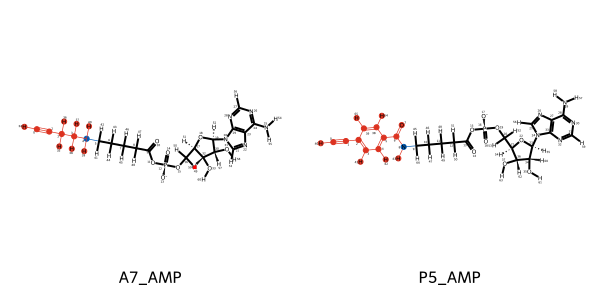

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'score': 0.19204990862075408}


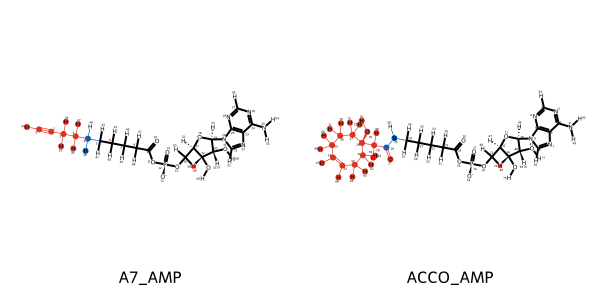

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'score': 0.24659696394160643}


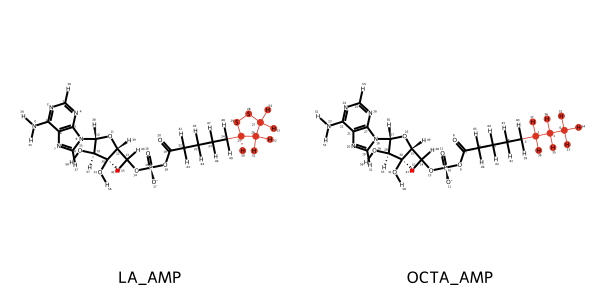

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'score': 0.7408182206817179}


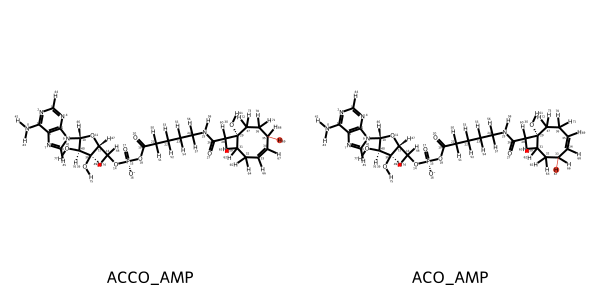

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'score': 0.3499377491111554}


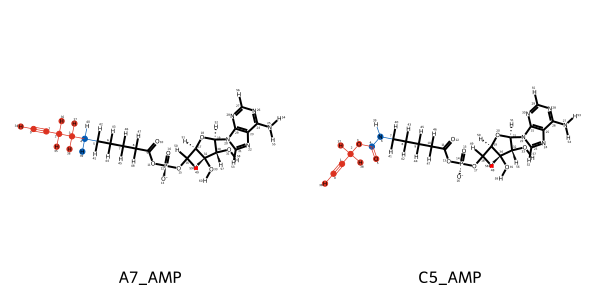

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'score': 0.23457028809379762}


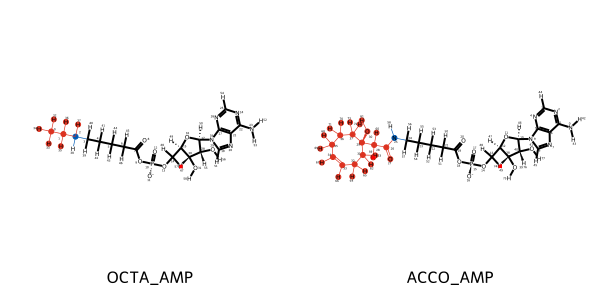

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'score': 0.28650479686019004}


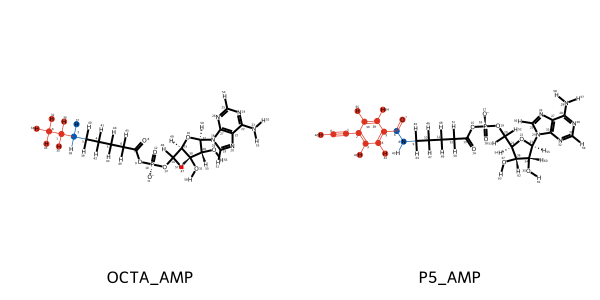

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'score': 0.8187307530779818}


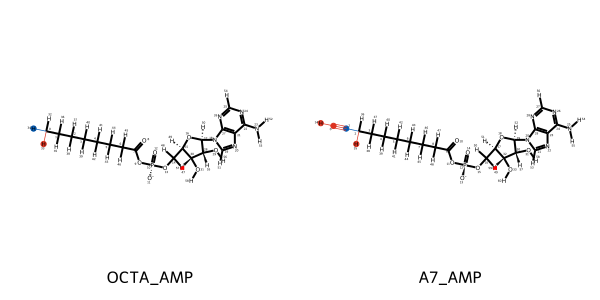

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [12]:
for mapping in ligand_network.edges:
    print(mapping.annotations)
    display(mapping)
    display(mapping.view_3d(show_atomIDs=True))

## Creating `Transformation`s

The `LigandNetwork` only knows about the small molecules and the alchemical connections between them. It doesn't know anything about environment (e.g., solvent) or about the `Protocol` that will be used during the simulation.

That information is included in a `Transformation`. Each of these transformations corresponds to a single leg of the simulation campaign, so for each edge in the `LigandNetwork`, we will create two `Transformation`s: one for the complex and one for solvent.

Before building the transformations, we need to set up the shared components: a `SolventComponent`, a `ProteinComponent`, and two `Protocol`s (one per leg with different solvent padding).

### Creating `ChemicalSystem`s

OpenFE describes complex molecular systems as being composed of `Component`s. For example, we have `SmallMoleculeComponent` for each small molecule in the `LigandNetwork`. We'll create a `SolventComponent` to describe the solvent, and binding free energy calculations involve a `ProteinComponent`.

The `Component`s are joined in a `ChemicalSystem`, which describes all the particles in the simulation.

In [13]:
# defaults are water with NaCl at 0.15 M
solvent = SolventComponent()

In [14]:
protein = ProteinComponent.from_pdb_file(str(FIXED_PROTEIN_PATH), name=FIXED_PROTEIN_PATH.stem)

### Creating a `Protocol`

The actual simulation is performed by a `Protocol`. We'll use an OpenMM-based hybrid topology relative free energy `Protocol`.

The easiest way to customize protocol settings is to start with the default settings, and modify them. Many settings carry units with them.

We use the default settings with an adapted solvent padding for the complex phase to avoid adding too many waters.

**Note: Since [OpenFE v1.5.0](https://docs.openfree.energy/en/v1.6.1/CHANGELOG.html#v1-5-0), `real_time_analysis_interval` does not need to be divisible by `checkpoint_interval`.**

**Note: by default the settings use a solvent padding of 1.5 nm, this is appropriate for solvent simulations, but for complex simulations this leads to excess water being in the box, slowing down your simulation. To deal with this, we will create two sets of settings, and two sets of protocols, one for each leg of the transformations.**

In [15]:
complex_settings = RelativeHybridTopologyProtocol.default_settings()

# Change the value
complex_settings.protocol_repeats = REPEATS
complex_settings.thermo_settings.temperature = TEMPERATURE * unit.kelvin
complex_settings.thermo_settings.ph = PH
complex_settings.simulation_settings.production_length = PRODUCTION_LENGTH * unit.nanosecond
complex_settings.simulation_settings.n_replicas = N_REPLICAS
complex_settings.lambda_settings.lambda_windows = LAMBDA_WINDOWS

# Reduce the solvent padding for the complex phase
complex_settings.solvation_settings.solvent_padding = 1.0 * unit.nanometer

complex_protocol = RelativeHybridTopologyProtocol(complex_settings)

complex_settings

{'alchemical_settings': {'endstate_dispersion_correction': False,
                         'explicit_charge_correction': False,
                         'explicit_charge_correction_cutoff': {'unit': 'nanometer',
                                                               'val': 0.8},
                         'softcore_LJ': 'gapsys',
                         'softcore_alpha': 0.85,
                         'turn_off_core_unique_exceptions': False,
                         'use_dispersion_correction': False},
 'engine_settings': {'compute_platform': 'cuda', 'gpu_device_index': None},
 'forcefield_settings': {'constraints': 'hbonds',
                         'forcefields': ['amber/ff14SB.xml',
                                         'amber/tip3p_standard.xml',
                                         'amber/tip3p_HFE_multivalent.xml',
                                         'amber/phosaa10.xml'],
                         'hydrogen_mass': 3.0,
                         'nonbonded_cutof

In [16]:
solvent_settings = RelativeHybridTopologyProtocol.default_settings()

# Change the value
solvent_settings.protocol_repeats = REPEATS
solvent_settings.thermo_settings.temperature = TEMPERATURE * unit.kelvin
solvent_settings.thermo_settings.ph = PH
solvent_settings.simulation_settings.production_length = PRODUCTION_LENGTH * unit.nanosecond
solvent_settings.simulation_settings.n_replicas = N_REPLICAS
solvent_settings.lambda_settings.lambda_windows = LAMBDA_WINDOWS

# Keep the default solvent padding
solvent_settings.solvation_settings.solvent_padding = 1.5 * unit.nanometer

solvent_protocol = RelativeHybridTopologyProtocol(solvent_settings)

solvent_settings

{'alchemical_settings': {'endstate_dispersion_correction': False,
                         'explicit_charge_correction': False,
                         'explicit_charge_correction_cutoff': {'unit': 'nanometer',
                                                               'val': 0.8},
                         'softcore_LJ': 'gapsys',
                         'softcore_alpha': 0.85,
                         'turn_off_core_unique_exceptions': False,
                         'use_dispersion_correction': False},
 'engine_settings': {'compute_platform': 'cuda', 'gpu_device_index': None},
 'forcefield_settings': {'constraints': 'hbonds',
                         'forcefields': ['amber/ff14SB.xml',
                                         'amber/tip3p_standard.xml',
                                         'amber/tip3p_HFE_multivalent.xml',
                                         'amber/phosaa10.xml'],
                         'hydrogen_mass': 3.0,
                         'nonbonded_cutof

### Creating the `Transformation`

Once we have the mapping, the two `ChemicalSystem`s, and the `Protocol`, creating the `Transformation` is easy:

Each `Transformation` contains:
- chemical models of both sides of the alchemical transformation in `stateA` and `stateB`
- the correspondence of atoms between the two sides in `mapping`
- a description of the exact computational algorithm to use (`complex_protocol` for the complex leg, `solvent_protocol` for the solvent leg)

### Building the `Transformation`s

With the mapping, the `ChemicalSystem`s, and the `Protocol`s in place, we loop over every edge in the `LigandNetwork` and create two `Transformation`s per edge (one complex leg, one solvent leg):

Alternatively, `RBFEAlchemicalNetworkPlanner` can build an `AlchemicalNetwork` in a single call. Here we construct it manually to show each step explicitly.

In [17]:
transformations = []
for mapping in ligand_network.edges:
    for leg in ["solvent", "complex"]:
        # use the solvent and protein created above
        sysA_dict = {"ligand": mapping.componentA, "solvent": solvent}
        sysB_dict = {"ligand": mapping.componentB, "solvent": solvent}

        if leg == "complex":
            # If this is a complex transformation we use the complex protocol
            # and add in the protein to the chemical states
            protocol = complex_protocol
            sysA_dict["protein"] = protein
            sysB_dict["protein"] = protein
        else:
            # If this is a solvent transformation we just use the solvent protocol
            protocol = solvent_protocol

        # we don't have to name objects, but it can make things (like filenames) more convenient
        sysA = ChemicalSystem(sysA_dict, name=f"{mapping.componentA.name}_{leg}")
        sysB = ChemicalSystem(sysB_dict, name=f"{mapping.componentB.name}_{leg}")

        prefix = "rbfe_"  # prefix is only to exactly reproduce CLI

        transformation = Transformation(
            stateA=sysA,
            stateB=sysB,
            mapping=mapping,
            protocol=protocol,  # use protocol created above
            name=f"{prefix}{sysA.name}_{sysB.name}",
        )
        transformations.append(transformation)

network = AlchemicalNetwork(transformations)

## Writing the `AlchemicalNetwork` to disk

We'll write out each transformation to disk, so that they can be run independently using the `openfe quickrun` command:

In [18]:
# We write out each transformation
for transformation in network.edges:
    transformation.to_json(TRANSFORMATION_DIR / f"{transformation.name}.json")

# List contents of the transformations directory
os.listdir(TRANSFORMATION_DIR)

['rbfe_LA_AMP_complex_A7_AMP_complex.json',
 'rbfe_C5_AMP_solvent_BCN_AMP_solvent.json',
 'rbfe_ACCO_AMP_complex_ACO_AMP_complex.json',
 'rbfe_C5_AMP_complex_BCN_AMP_complex.json',
 'rbfe_OCTA_AMP_solvent_P5_AMP_solvent.json',
 'rbfe_ACCO_AMP_solvent_ACO_AMP_solvent.json',
 'rbfe_A7_AMP_complex_C5_AMP_complex.json',
 'rbfe_OCTA_AMP_complex_ACCO_AMP_complex.json',
 'rbfe_LA_AMP_solvent_A7_AMP_solvent.json',
 'rbfe_A7_AMP_complex_ACO_AMP_complex.json',
 'rbfe_OCTA_AMP_solvent_C5_AMP_solvent.json',
 'rbfe_OCTA_AMP_solvent_A7_AMP_solvent.json',
 'rbfe_A7_AMP_solvent_C5_AMP_solvent.json',
 'rbfe_OCTA_AMP_complex_P5_AMP_complex.json',
 'rbfe_OCTA_AMP_complex_ACO_AMP_complex.json',
 'rbfe_A7_AMP_solvent_ACO_AMP_solvent.json',
 'rbfe_OCTA_AMP_complex_C5_AMP_complex.json',
 'rbfe_A7_AMP_solvent_ACCO_AMP_solvent.json',
 'rbfe_OCTA_AMP_solvent_ACO_AMP_solvent.json',
 'rbfe_OCTA_AMP_solvent_ACCO_AMP_solvent.json',
 'rbfe_LA_AMP_solvent_OCTA_AMP_solvent.json',
 'rbfe_OCTA_AMP_complex_BCN_AMP_comple

Each of these individual `.json` files contains a `Transformation`, which contains all the information to run the calculation.  These could be farmed out as individual jobs on a HPC cluster. These files are identical to what were created in setup stage of the CLI tutorial; for details on running them, follow from the section on running simulations in the CLI tutorial

## SepTop Relative Binding Free Energy Transformations

Unlike the hybrid topology RBFE above, SepTop simulates both the complex and solvent legs in a single run. There is therefore one transformation per network edge (no separate solvent leg).

In [19]:
septop_settings = SepTopProtocol.default_settings()

septop_settings.protocol_repeats = REPEATS
septop_settings.thermo_settings.temperature = TEMPERATURE * unit.kelvin
septop_settings.thermo_settings.ph = PH

# lambda windows are handled by the septop protocol internally

septop_settings.complex_simulation_settings.production_length = PRODUCTION_LENGTH * unit.nanosecond
septop_settings.solvent_simulation_settings.production_length = PRODUCTION_LENGTH * unit.nanosecond

septop_protocol = SepTopProtocol(septop_settings)

septop_settings

{'alchemical_settings': {'annihilate_sterics': False,
                         'disable_alchemical_dispersion_correction': False,
                         'softcore_a': 1.0,
                         'softcore_alpha': 0.5,
                         'softcore_b': 1.0,
                         'softcore_c': 6.0},
 'complex_equil_output_settings': {'checkpoint_interval': {'unit': 'nanosecond',
                                                           'val': 1.0},
                                   'checkpoint_storage_filename': 'checkpoint.chk',
                                   'equil_npt_structure': 'equil_npt',
                                   'equil_nvt_structure': None,
                                   'forcefield_cache': 'db.json',
                                   'log_output': 'equil_simulation',
                                   'minimized_structure': 'minimized',
                                   'output_indices': 'all',
                                   'preminimized_st

In [20]:
septop_transformations = []
for mapping in ligand_network.edges:
    ligA, ligB = mapping.componentA, mapping.componentB
    stateA = ChemicalSystem(
        {"ligand": ligA, "protein": protein, "solvent": solvent},
        name=f"{ligA.name}_complex",
    )
    stateB = ChemicalSystem(
        {"ligand": ligB, "protein": protein, "solvent": solvent},
        name=f"{ligB.name}_complex",
    )

    prefix = "rbfe_"  # prefix is only to exactly reproduce CLI

    septop_transformations.append(
        Transformation(
            stateA=stateA,
            stateB=stateB,
            mapping=None,
            protocol=septop_protocol,
            name=f"{prefix}{ligA.name}_{ligB.name}_septop",
        )
    )

for t in septop_transformations:
    t.to_json(SEPTOP_TRANSFORMATION_DIR / f"{t.name}.json")

os.listdir(SEPTOP_TRANSFORMATION_DIR)

['rbfe_OCTA_AMP_P5_AMP_septop.json',
 'rbfe_LA_AMP_A7_AMP_septop.json',
 'rbfe_A7_AMP_P5_AMP_septop.json',
 'rbfe_OCTA_AMP_C5_AMP_septop.json',
 'rbfe_A7_AMP_ACCO_AMP_septop.json',
 'rbfe_ACCO_AMP_ACO_AMP_septop.json',
 'rbfe_OCTA_AMP_A7_AMP_septop.json',
 'rbfe_A7_AMP_ACO_AMP_septop.json',
 'rbfe_LA_AMP_OCTA_AMP_septop.json',
 'rbfe_OCTA_AMP_ACCO_AMP_septop.json',
 'rbfe_A7_AMP_C5_AMP_septop.json',
 'rbfe_C5_AMP_BCN_AMP_septop.json',
 'rbfe_OCTA_AMP_ACO_AMP_septop.json',
 'rbfe_OCTA_AMP_BCN_AMP_septop.json']